### Importing necessary modules

In [2]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                                     # type: ignore
import tensorflow as tf                                                                 # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (5,5)
from joblib import dump, load                                                           # type: ignore
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

### Importing dataset

In [3]:
test_data = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-test-5nearest-dakar-with-storm-size.csv", index_col=False)

In [4]:
test_data.shape

(17876, 31)

#### combining dataset and doing some exploratory analysis

In [4]:
test_data = test_data.dropna()

In [5]:
test_data.shape

(17771, 31)

In [6]:
hour_0 = "00"
minute_0 = "00"

In [7]:
query = f"`hour`=={nflics.format(hour_0)} and `minute`=={nflics.format(minute_0)}"
test_data = test_data.query(query).reset_index(drop=True)

In [8]:
test_data.shape

(216, 31)

In [9]:
pcX0 = pd.read_csv(f"/home/mendrika/mendrika-phd/data/nflics/pcX0/pcX0-{hour_0}-{minute_0}.csv", index_col=None)
to_keep = pcX0["index"].values
to_drop = [i for i in range(len(test_data)) if i not in to_keep]

In [10]:
test_data = test_data.drop(index=to_drop)

#### Choosing field to include in the data

In [11]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')
data = test_data[field]

### Exploratory data analysis

In [12]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [13]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [14]:
def correct_coord(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if "lat" in key and i == -9999:
                transformed.append(14)
            elif "lon" in key and i == -9999:
                transformed.append(-5)
            else:
                transformed.append(i)
        df_copy[key] = transformed
    return df_copy

In [15]:
def correct_distance(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i == 999999:
                transformed.append(430)
            else:
                transformed.append(i)
        df_copy[key] = transformed
    return df_copy

In [16]:
test_data = correct_coord(test_data, location.split(',')[:-1])
test_data = correct_distance(test_data, distance.split(',')[:-1])

In [17]:
original_test_data = test_data.copy()

In [18]:
to_scale = wavelet_power + storm_size + distance

In [19]:
transform = True
if transform:
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [20]:
x_test = test_data.drop([target_index], axis=1)
y_test = test_data[target_index]

In [21]:
model = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/best_model_new_format_Dakar_nearest5_corrected.keras")

In [22]:
scaler = load('std_scaler_best_model_new_format_Dakar_nearest5_corrected.bin')

#### Normalising the features

In [23]:
x_test_std = scaler.transform(x_test)

### Model prediction

In [24]:
y_hat_model = model.predict(x_test_std)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [25]:
bs_model = brier_score_loss(y_test, y_hat_model)
print(f"Model BS: {bs_model:.4f}")

Model BS: 0.0365


### Unconditional probability

In [26]:
pc = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/unconditional-probability/dataset-pc-31.csv")

In [27]:
Cb_Dakar_unc = []
for i in range(len(original_test_data)):
    minute = original_test_data["minute"].values[i]    
    hour = original_test_data["hour"].values[i] + 1
    if hour != 24:    
        index_hour = pc["hour"].values == hour
    else:
        index_hour = pc["hour"].values == 0
    index_minute = pc["minute"].values == minute
    index = index_hour * index_minute
    Cb_Dakar_unc.append(pc["probability"].values[index])
Cb_Dakar_unc = np.array(Cb_Dakar_unc)

In [28]:
bs_ref_unc = brier_score_loss(y_test, Cb_Dakar_unc)
print(f"BS climatology: {bs_ref_unc:.4f}")

BS climatology: 0.0954


In [29]:
bss_clim = 1 - (bs_model/bs_ref_unc)
print(f"BSS climatology: {bss_clim:.2f}")

BSS climatology: 0.62


### Conditional probability

In [30]:
cond_prob = pcX0["pcX0"].values

In [31]:
bs_ref_cond = brier_score_loss(y_test, cond_prob)
print(f"BS NFLICS: {bs_ref_cond:.4f}")

BS NFLICS: 0.0619


In [32]:
bss_nflics = 1 - (bs_model/bs_ref_cond)
print(f"BSS NFLICS: {bss_nflics:.2f}")

BSS NFLICS: 0.41


### ROC

In [33]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)  
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.title(f"{hour_0}:{minute_0} UTC")
  plt.xlim([0,100])
  plt.ylim([0,105])
  ax = plt.gca()
  ax.set_aspect('equal')
  plt.tight_layout()
  plt.legend(loc='lower right');
  plt.savefig(f"/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-05-13/roc-no-resampling-case-study={hour_0}{minute_0}.png")

In [34]:
auc_model = roc_auc_score(y_test, y_hat_model)
auc_unc = roc_auc_score(y_test, Cb_Dakar_unc)
auc_cond = roc_auc_score(y_test, cond_prob)

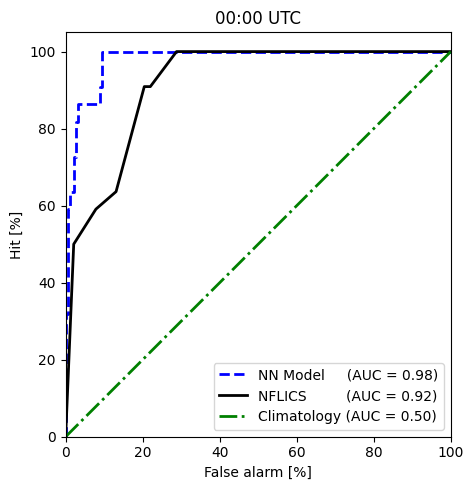

In [35]:
plot_roc(f"NN Model     (AUC = {auc_model:.2f})", y_test, y_hat_model, color="blue", linestyle='--')
plot_roc(f"NFLICS         (AUC = {auc_cond:.2f})", y_test, cond_prob, color="black", linestyle='-')
plot_roc(f"Climatology (AUC = {auc_unc:.2f})", y_test, Cb_Dakar_unc, color="green", linestyle='-.')

### Confusion matrix

In [36]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title(f"{hour_0}:{minute_0} UTC")
    plt.tight_layout()
    plt.savefig(f"/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-05-13/cm-no-resampling-case-study={hour_0}{minute_0}.png")
    plt.show()

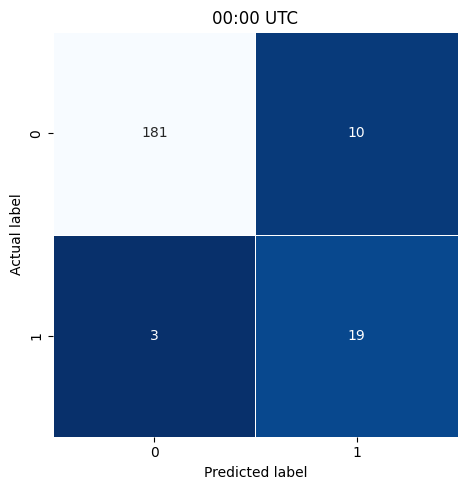

In [37]:
plot_cm(y_test, y_hat_model, 0.1)

### Reliability curve

In [38]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

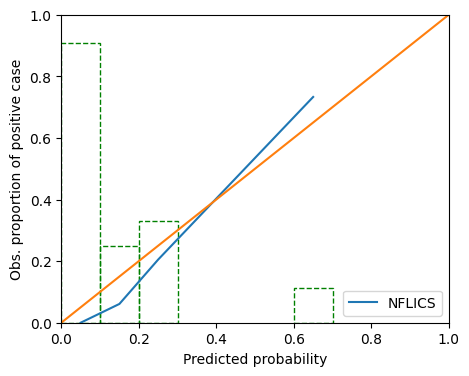

In [39]:
#prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, cond_prob.flatten(), bin_size=0.1, count_pred_per_bin=10)
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, cond_prob.flatten(), bin_size=0.1, count_pred_per_bin=1)

plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NFLICS")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()
plt.show()

In [40]:
with open("/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-05-13/different-lead-times.csv", "+a") as f:
    f.write(f"{nflics.format(hour_0)},{bss_clim},{bss_nflics}\n")